### Mar 11 quadratic zeeman

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [4]:
freq = 7.2
savename = "10s measurement Mar 13 - 7p2MHz"
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 13 measurement/7p2MHz_10s.csv')

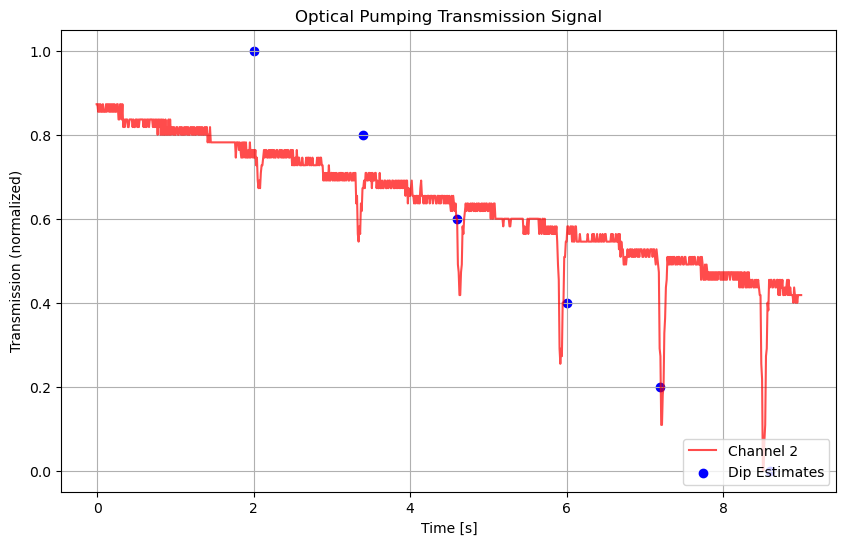

In [12]:
t0 = 2
tf = 11
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([2,3.4,4.6,6,7.2,8.6])

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [13]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4",  "h5", "g5", "x0_5",  "h6", "g6", "x0_6"]
p0 = (1, -0.02, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.8622055889642781
m -0.04843877727873389
h1 0.09068880544484183
g1 0.024384869033157633
x0_1 2.0684973872234953
h2 0.15626754259484749
g2 0.022473737606381994
x0_2 3.3451759895459445
h3 0.23641516516795763
g3 0.022740218336876596
x0_3 4.6355774019559295
h4 0.3427537577359536
g4 0.023246940696469737
x0_4 5.9275267364927435
h5 0.432601400420992
g5 0.022948281994018018
x0_5 7.220493304540655
h6 0.4860596364923578
g6 0.02119541237843893
x0_6 8.520857616330504


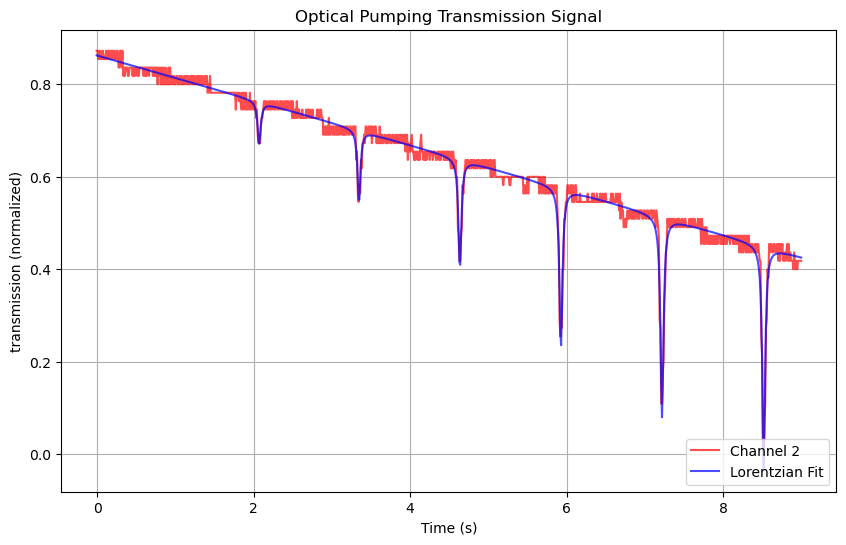

In [14]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)


In [15]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0
x0_5_u = ufloat(popt[16], perr[16]) + t0
x0_6_u = ufloat(popt[19], perr[19]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)
x0_5_index = int(x0_5_u.n // dt)
x0_6_index = int(x0_6_u.n // dt)

numAvg = 10


vMeasured = 0.885  # V
vShift = ufloat(vMeasured,0.002 * vMeasured) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(3.012,0.031) # taken from 195kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]) / np.sqrt(2*numAvg))
v_5 = ufloat(np.mean(y1[x0_5_index - numAvg : x0_5_index + numAvg]),
             np.std(y1[x0_5_index - numAvg : x0_5_index + numAvg]) / np.sqrt(2*numAvg))
v_6 = ufloat(np.mean(y1[x0_6_index - numAvg : x0_6_index + numAvg]),
             np.std(y1[x0_6_index - numAvg : x0_6_index + numAvg]) / np.sqrt(2*numAvg))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100)
VtoBHoriz = ufloat(2*8.8*10**(-4),2*8.8*10**(-4) / 100)

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip5 = (v_5-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip6 = (v_6-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")
print(f"B field of dip 5: {dip5:.3e}")
print(f"B field of dip 6: {dip6:.3e}")

B field of dip 1: (1.396+/-0.016)e-03
B field of dip 2: (1.403+/-0.016)e-03
B field of dip 3: (1.410+/-0.016)e-03
B field of dip 4: (1.417+/-0.016)e-03
B field of dip 5: (1.424+/-0.016)e-03
B field of dip 6: (1.432+/-0.016)e-03


In [16]:
filepath = 'models/quadraticRb85ZeemanData.csv'

m.append_to_sextupleZeeman_csv(freq, (dip1,dip2,dip3,dip4,dip5,dip6), filepath)

In [17]:
freq = 10.8
savename = "10s measurement Mar 13 - 10p8MHz"
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 13 measurement/10p8MHz_10s.csv')

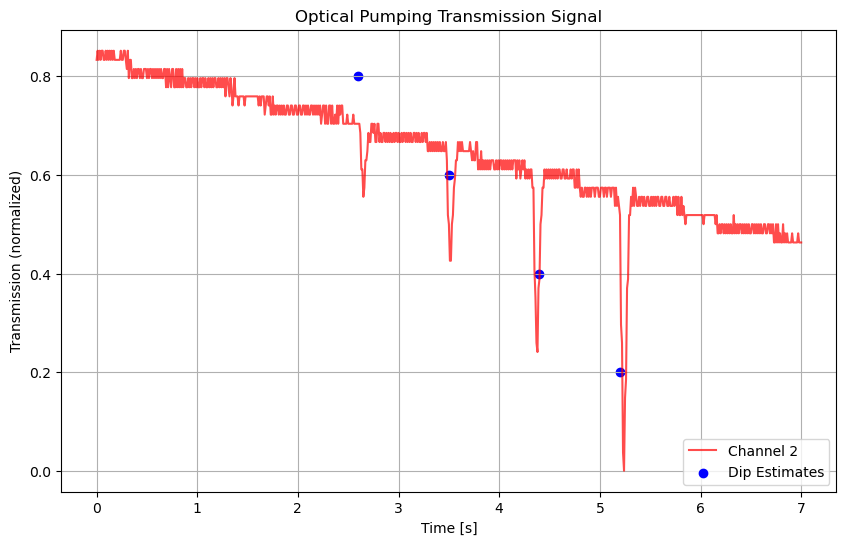

In [20]:
t0 = 0
tf = 7
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([2.6,3.5,4.4,5.2])

m.plot_quadraticZeeman_quadruple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [22]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4"]
p0 = (1, -0.02, 1, 0.1, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,10,2,2,10,2,2,10,2,2,10)

# print(len(p0))
# print(len(variables))
# print(len(lower_bound))
# print(len(upper_bound))

bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.quadruple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.8416668897781125
m -0.05334427226424863
h1 0.14439989301387784
g1 0.01912243874070949
x0_1 2.6535007656419087
h2 0.24679515547221897
g2 0.019729281194377397
x0_2 3.5159457660229743
h3 0.38756785123540594
g3 0.0199795292224922
x0_3 4.375891243849986
h4 0.5866242226440154
g4 0.02030634370497971
x0_4 5.239168683518619


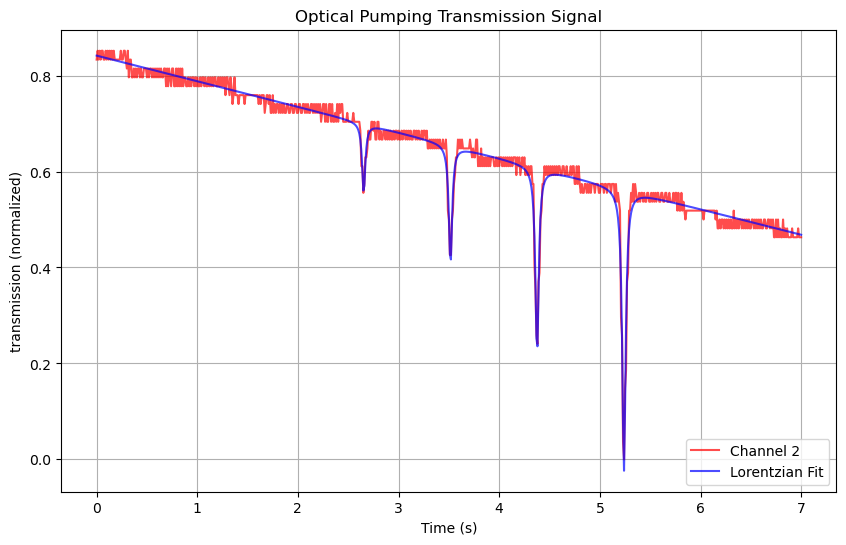

In [23]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.quadruple_lorentz, "fit to " + savename)


In [25]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)

numAvg = 10


vMeasured = 0.879  # V
vShift = ufloat(vMeasured,0.002 * vMeasured) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(3.012,0.031) # taken from 195kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]) / np.sqrt(2*numAvg))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100)
VtoBHoriz = ufloat(2*8.8*10**(-4),2*8.8*10**(-4) / 100)

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")

B field of dip 1: (1.407+/-0.016)e-03
B field of dip 2: (1.412+/-0.016)e-03
B field of dip 3: (1.416+/-0.016)e-03
B field of dip 4: (1.421+/-0.016)e-03


In [26]:
filepath = 'models/quadraticRb87ZeemanData.csv'

m.append_to_quadrupleZeeman_csv(freq, (dip1,dip2,dip3,dip4), filepath)